In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the processed features
processed_path = Path.cwd().parent / 'data' / 'processed'
df = pd.read_csv(processed_path / 'features.csv')

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['final_result'].value_counts())

Shape: (32593, 29)

Target distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

# Define which columns to use as features
feature_columns = [
    'gender_encoded',
    'disability_encoded', 
    'age_encoded',
    'education_encoded',
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'avg_daily_clicks',
    'active_days',
    'max_clicks_day',
    'early_clicks',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments',
    'num_late_submissions',
    'late_submission_rate',
    'stayed_enrolled',
    'avg_registration_date'
]

# Features (X) and target (y)
X = df[feature_columns]
y = df['final_result']

# Encode target variable to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature matrix shape:", X.shape)
print("\nTarget classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))

Feature matrix shape: (32593, 19)

Target classes: ['Distinction' 'Fail' 'Pass' 'Withdrawn']
Encoded as: [0, 1, 2, 3]


In [7]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # ensures equal class distribution in both sets
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(le.classes_, counts):
    print(f"  {cls}: {count}")

Training set size: (26074, 19)
Test set size: (6519, 19)

Training target distribution:
  Distinction: 2419
  Fail: 5641
  Pass: 9889
  Withdrawn: 8125


In [8]:
from sklearn.preprocessing import StandardScaler

# Scale features - important for many ML algorithms
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("Mean of first feature (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std of first feature (should be ~1):", X_train_scaled[:, 0].std().round(4))

Features scaled successfully!
Mean of first feature (should be ~0): -0.0
Std of first feature (should be ~1): 1.0


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1  # uses all CPU cores
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Results
print("=== Random Forest Results ===\n")
print(classification_report(y_test, y_pred_rf, 
                           target_names=le.classes_))

=== Random Forest Results ===

              precision    recall  f1-score   support

 Distinction       0.61      0.44      0.51       605
        Fail       0.78      0.66      0.71      1411
        Pass       0.70      0.83      0.76      2472
   Withdrawn       0.89      0.86      0.87      2031

    accuracy                           0.77      6519
   macro avg       0.74      0.70      0.71      6519
weighted avg       0.77      0.77      0.76      6519



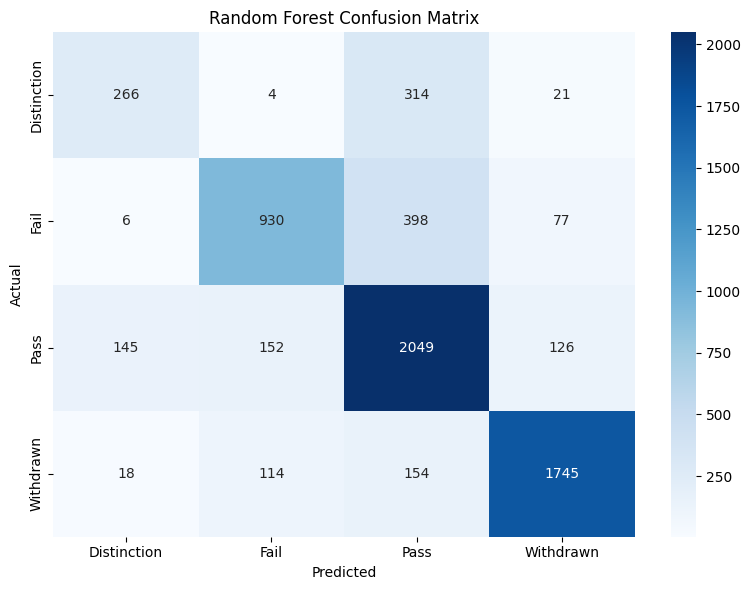

In [10]:
# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_13565/3878144428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature',


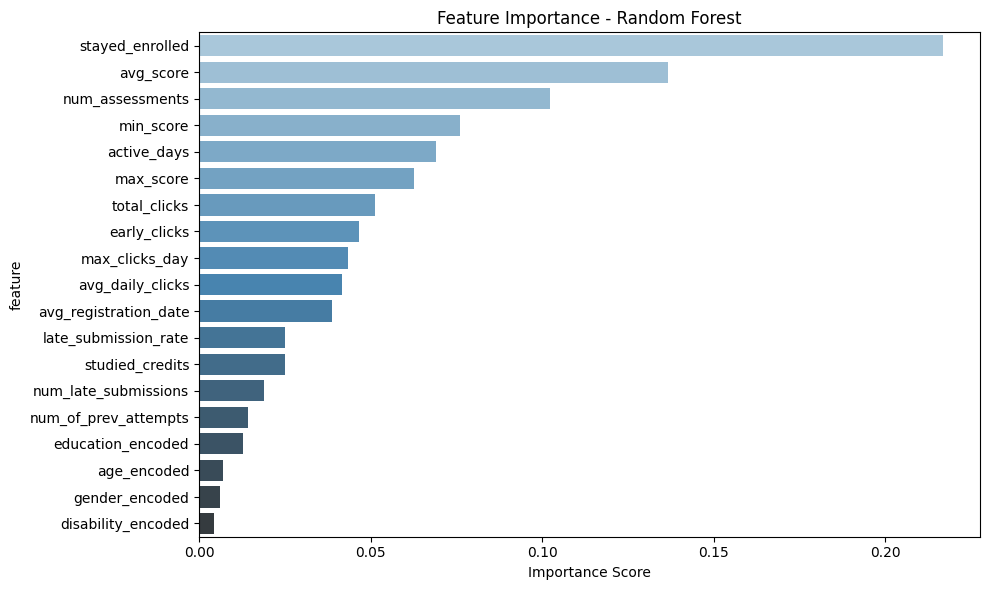


Top 5 most important features:
            feature  importance
17  stayed_enrolled    0.216772
11        avg_score    0.136781
14  num_assessments    0.102423
13        min_score    0.076161
8       active_days    0.069179


In [11]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature',
            palette='Blues_d')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head())

In [12]:
# Remove stayed_enrolled as it causes data leakage
feature_columns_clean = [
    'gender_encoded',
    'disability_encoded', 
    'age_encoded',
    'education_encoded',
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'avg_daily_clicks',
    'active_days',
    'max_clicks_day',
    'early_clicks',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments',
    'num_late_submissions',
    'late_submission_rate',
    'avg_registration_date'
]

# Retrain with clean features
X_clean = df[feature_columns_clean]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale
scaler_clean = StandardScaler()
X_train_c_scaled = scaler_clean.fit_transform(X_train_c)
X_test_c_scaled = scaler_clean.transform(X_test_c)

# Retrain model
rf_clean = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train_c_scaled, y_train_c)
y_pred_clean = rf_clean.predict(X_test_c_scaled)

print("=== Random Forest Results (No Data Leakage) ===\n")
print(classification_report(y_test_c, y_pred_clean,
                           target_names=le.classes_))

=== Random Forest Results (No Data Leakage) ===

              precision    recall  f1-score   support

 Distinction       0.62      0.45      0.53       605
        Fail       0.51      0.37      0.43      1411
        Pass       0.69      0.83      0.76      2472
   Withdrawn       0.68      0.70      0.69      2031

    accuracy                           0.66      6519
   macro avg       0.63      0.59      0.60      6519
weighted avg       0.64      0.66      0.64      6519



In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_c_scaled, y_train_c)
y_pred_gb = gb_model.predict(X_test_c_scaled)

print("=== Gradient Boosting Results ===\n")
print(classification_report(y_test_c, y_pred_gb,
                           target_names=le.classes_))

=== Gradient Boosting Results ===

              precision    recall  f1-score   support

 Distinction       0.61      0.47      0.53       605
        Fail       0.52      0.39      0.44      1411
        Pass       0.71      0.84      0.77      2472
   Withdrawn       0.69      0.71      0.70      2031

    accuracy                           0.67      6519
   macro avg       0.63      0.60      0.61      6519
weighted avg       0.65      0.67      0.66      6519



In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    multi_class='multinomial'
)

lr_model.fit(X_train_c_scaled, y_train_c)
y_pred_lr = lr_model.predict(X_test_c_scaled)

print("=== Logistic Regression Results ===\n")
print(classification_report(y_test_c, y_pred_lr,
                           target_names=le.classes_))

=== Logistic Regression Results ===

              precision    recall  f1-score   support

 Distinction       0.39      0.84      0.53       605
        Fail       0.45      0.47      0.46      1411
        Pass       0.74      0.56      0.64      2472
   Withdrawn       0.72      0.65      0.68      2031

    accuracy                           0.60      6519
   macro avg       0.57      0.63      0.58      6519
weighted avg       0.64      0.60      0.60      6519



/Users/masi/Desktop/Projects/student-early-warning-system/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [15]:
import pickle
from pathlib import Path

# Save the model and scaler
models_path = Path.cwd().parent / 'models'

# Save model
with open(models_path / 'model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)

# Save scaler
with open(models_path / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler_clean, f)

# Save label encoder
with open(models_path / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save feature columns
with open(models_path / 'features.pkl', 'wb') as f:
    pickle.dump(feature_columns_clean, f)

print("Model saved successfully!")
print(f"Saved to: {models_path}")

Model saved successfully!
Saved to: /Users/masi/Desktop/Projects/student-early-warning-system/models


In [16]:
# Engineer better features
df_improved = df.copy()

# Click consistency score
df_improved['click_consistency'] = (
    df_improved['total_clicks'] / (df_improved['active_days'] + 1)
)

# Early engagement ratio - how active were they early vs overall
df_improved['early_engagement_ratio'] = (
    df_improved['early_clicks'] / (df_improved['total_clicks'] + 1)
)

# Assessment completion rate
df_improved['assessment_completion_rate'] = (
    df_improved['num_assessments'] / (df_improved['num_assessments'].max())
)

# Score consistency
df_improved['score_range'] = (
    df_improved['max_score'] - df_improved['min_score']
)

# Struggle indicator
df_improved['struggle_score'] = (
    df_improved['num_late_submissions'] * 0.3 +
    (1 - df_improved['avg_score'] / 100) * 0.4 +
    (1 - df_improved['early_clicks'] / (df_improved['total_clicks'] + 1)) * 0.3
)

print("New features created!")
print(df_improved[['click_consistency', 
                    'early_engagement_ratio',
                    'assessment_completion_rate',
                    'score_range',
                    'struggle_score']].head())

New features created!
   click_consistency  early_engagement_ratio  assessment_completion_rate  \
0           4.741117                0.453476                    0.178571   
1           3.329466                0.430362                    0.178571   
2           3.649351                0.996454                    0.000000   
3           3.250000                0.250116                    0.178571   
4           2.929178                0.547826                    0.178571   

   score_range  struggle_score  
0          7.0        0.235957  
1         10.0        0.905291  
2          0.0        0.401064  
3         17.0        0.320965  
4         45.0        1.818052  


In [17]:
feature_columns_improved = [
    # Original features
    'gender_encoded',
    'disability_encoded', 
    'age_encoded',
    'education_encoded',
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'avg_daily_clicks',
    'active_days',
    'max_clicks_day',
    'early_clicks',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments',
    'num_late_submissions',
    'late_submission_rate',
    'avg_registration_date',
    # New features
    'click_consistency',
    'early_engagement_ratio',
    'assessment_completion_rate',
    'score_range',
    'struggle_score'
]

# Prepare data
X_improved = df_improved[feature_columns_improved]
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_improved, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale
scaler_improved = StandardScaler()
X_train_i_scaled = scaler_improved.fit_transform(X_train_i)
X_test_i_scaled = scaler_improved.transform(X_test_i)

print("Data prepared with improved features!")
print("Feature count:", len(feature_columns_improved))

Data prepared with improved features!
Feature count: 23


In [19]:
pip install imbalanced-learn

     |████████████████████████████████| 258 kB 1.6 MB/s eta 0:00:01
You should consider upgrading via the '/Users/masi/Desktop/Projects/student-early-warning-system/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Install imbalanced-learn
# Run in terminal: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_i_scaled, y_train_i
)

print("Before SMOTE:")
unique, counts = np.unique(y_train_i, return_counts=True)
for cls, count in zip(le.classes_, counts):
    print(f"  {cls}: {count}")

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_resampled, return_counts=True)
for cls, count in zip(le.classes_, counts):
    print(f"  {cls}: {count}")

/Users/masi/Desktop/Projects/student-early-warning-system/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Before SMOTE:
  Distinction: 2419
  Fail: 5641
  Pass: 9889
  Withdrawn: 8125

After SMOTE:
  Distinction: 9889
  Fail: 9889
  Pass: 9889
  Withdrawn: 9889


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

# Tuned model
gb_improved = GradientBoostingClassifier(
    n_estimators=300,      # more trees
    max_depth=5,           # slightly shallower
    learning_rate=0.05,    # slower learning = better generalization
    min_samples_split=50,  # prevents overfitting
    min_samples_leaf=20,   # prevents overfitting
    subsample=0.8,         # uses 80% of data per tree
    random_state=42
)

gb_improved.fit(X_train_resampled, y_train_resampled)
y_pred_improved = gb_improved.predict(X_test_i_scaled)

print("=== Improved Model Results ===\n")
print(classification_report(y_test_i, y_pred_improved,
                           target_names=le.classes_))

=== Improved Model Results ===

              precision    recall  f1-score   support

 Distinction       0.55      0.62      0.58       605
        Fail       0.52      0.47      0.49      1411
        Pass       0.73      0.78      0.76      2472
   Withdrawn       0.73      0.68      0.70      2031

    accuracy                           0.67      6519
   macro avg       0.63      0.64      0.63      6519
weighted avg       0.67      0.67      0.67      6519



In [22]:
import pickle
from pathlib import Path

models_path = Path.cwd().parent / 'models'

# Save improved model
with open(models_path / 'model.pkl', 'wb') as f:
    pickle.dump(gb_improved, f)

# Save improved scaler
with open(models_path / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler_improved, f)

# Save label encoder
with open(models_path / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save improved feature columns
with open(models_path / 'features.pkl', 'wb') as f:
    pickle.dump(feature_columns_improved, f)

print("Improved model saved successfully!")

Improved model saved successfully!


## Binary Classification Approach
Simplified to binary problem:
- At Risk = Fail + Withdrawn
- Not At Risk = Pass + Distinction

Rationale: More actionable for real intervention systems
and likely to improve accuracy significantly.

In [23]:
# Create binary target
df_improved['at_risk'] = df_improved['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)

print("Binary target distribution:")
print(df_improved['at_risk'].value_counts())
print("\nPercentages:")
print(df_improved['at_risk'].value_counts(normalize=True).round(3) * 100)

Binary target distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64

Percentages:
at_risk
1    52.8
0    47.2
Name: proportion, dtype: float64


In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
X_binary = df_improved[feature_columns_improved]
y_binary = df_improved['at_risk']

# Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Scale
scaler_binary = StandardScaler()
X_train_b_scaled = scaler_binary.fit_transform(X_train_b)
X_test_b_scaled = scaler_binary.transform(X_test_b)

# Train model
gb_binary = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    min_samples_split=50,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)

gb_binary.fit(X_train_b_scaled, y_train_b)
y_pred_binary = gb_binary.predict(X_test_b_scaled)

print("=== Binary Classification Results ===\n")
print(classification_report(y_test_b, y_pred_binary,
                           target_names=['Not At Risk', 'At Risk']))

=== Binary Classification Results ===

              precision    recall  f1-score   support

 Not At Risk       0.85      0.91      0.88      3077
     At Risk       0.92      0.86      0.89      3442

    accuracy                           0.88      6519
   macro avg       0.88      0.89      0.88      6519
weighted avg       0.89      0.88      0.88      6519



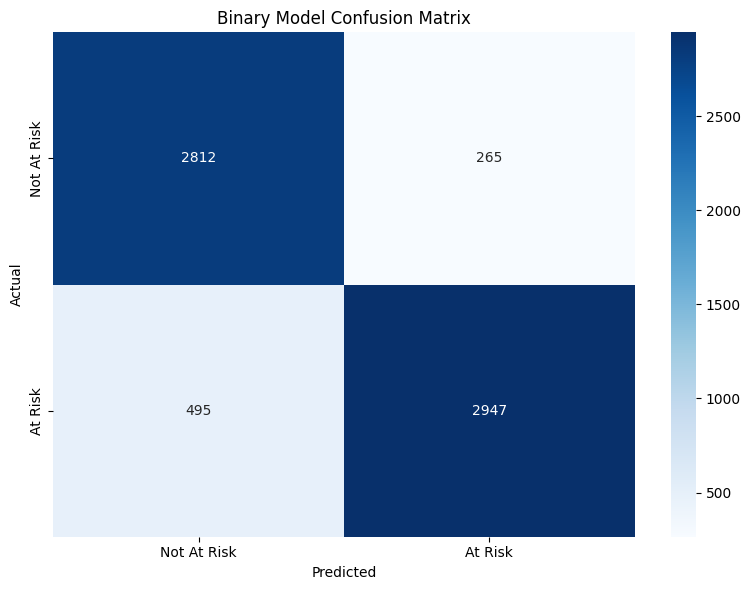

/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_13565/2996409473.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature',


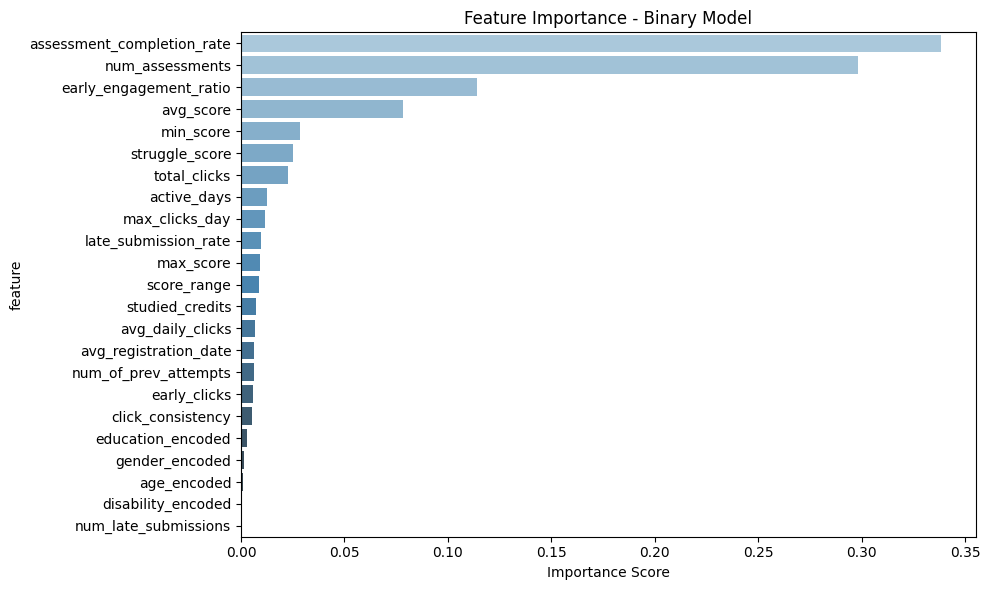


Top 5 most important features:
                       feature  importance
20  assessment_completion_rate    0.338205
14             num_assessments    0.298042
19      early_engagement_ratio    0.114037
11                   avg_score    0.078038
13                   min_score    0.028548


In [25]:
# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_b, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not At Risk', 'At Risk'],
            yticklabels=['Not At Risk', 'At Risk'])
plt.title('Binary Model Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_columns_improved,
    'importance': gb_binary.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature',
            palette='Blues_d')
plt.title('Feature Importance - Binary Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head())

In [26]:
import pickle
from pathlib import Path

models_path = Path.cwd().parent / 'models'

# Save binary model
with open(models_path / 'model_binary.pkl', 'wb') as f:
    pickle.dump(gb_binary, f)

# Save scaler
with open(models_path / 'scaler_binary.pkl', 'wb') as f:
    pickle.dump(scaler_binary, f)

# Save feature columns
with open(models_path / 'features_binary.pkl', 'wb') as f:
    pickle.dump(feature_columns_improved, f)

print("Binary model saved successfully!")

Binary model saved successfully!


In [27]:
# Get a real Not At Risk student
not_at_risk = df_improved[df_improved['at_risk'] == 0][feature_columns_improved].iloc[0]
print("=== Real Not At Risk Student ===")
print(not_at_risk.to_dict())

# Get a real At Risk student  
at_risk = df_improved[df_improved['at_risk'] == 1][feature_columns_improved].iloc[0]
print("\n=== Real At Risk Student ===")
print(at_risk.to_dict())

=== Real Not At Risk Student ===
{'gender_encoded': 1.0, 'disability_encoded': 0.0, 'age_encoded': 2.0, 'education_encoded': 3.0, 'num_of_prev_attempts': 0.0, 'studied_credits': 240.0, 'total_clicks': 934.0, 'avg_daily_clicks': 4.76530612244898, 'active_days': 196.0, 'max_clicks_day': 76.0, 'early_clicks': 424.0, 'avg_score': 82.0, 'max_score': 85.0, 'min_score': 78.0, 'num_assessments': 5.0, 'num_late_submissions': 0.0, 'late_submission_rate': 0.0, 'avg_registration_date': -159.0, 'click_consistency': 4.741116751269035, 'early_engagement_ratio': 0.453475935828877, 'assessment_completion_rate': 0.17857142857142858, 'score_range': 7.0, 'struggle_score': 0.2359572192513369}

=== Real At Risk Student ===
{'gender_encoded': 0.0, 'disability_encoded': 1.0, 'age_encoded': 1.0, 'education_encoded': 2.0, 'num_of_prev_attempts': 0.0, 'studied_credits': 60.0, 'total_clicks': 281.0, 'avg_daily_clicks': 3.6973684210526314, 'active_days': 76.0, 'max_clicks_day': 23.0, 'early_clicks': 281.0, 'avg_sc